In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import astropy as ast
from astropy.io import ascii, fits
import pandas as pd
import matplotlib.cm as cm
from matplotlib.colors import LogNorm, Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.interpolate import interp1d
#extinction imports
from astropy.table import Table, Column, MaskedColumn, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
# from zh_scraper import get_extinction
# from dustmaps.sfd import SFDQuery
# from dustmaps.edenhofer2023 import Edenhofer2023Query
# sfd = SFDQuery()
# eden = Edenhofer2023Query(integrated=True)
from view_and_clean import offset_corrector #individual_plotter, df_extract, individual_plotter_v2, df_extract_v2,
from metrics import sed_plotter, info, observed_sed, largest_amplitude #, fit_plotter_flux, fit_plotter_flux_v2, mean_med_flux, mean_med_flux_v2, offset_warning, offset_warning_v2,compute_lomb_scargle, plot_periodogram, plot_phase_fold 

In [2]:
coords = pd.read_csv('merged_smc_lmc_coords.csv', comment='#', sep="\\s+", names=['RA', 'DEC'])
df_lmc = pd.read_csv('./annas_candidates/final_lmc_ysgcands.csv', comment='#') # , sep="\\s+"
df_smc = pd.read_csv('./annas_candidates/final_smc_ysgcands.csv', comment='#') # , sep="\\s+"
# apassfile = pd.read_csv('UCAC4_match.csv')
# with fits.open('apass_match.fit') as hdul:
#     columns_to_keep = ['RAJ2000', 'DEJ2000', 'Bmag', 'e_Bmag', 'Vmag', 'e_Vmag', 'gmag', 'e_gmag', 'rmag', 'e_rmag', 'imag', 'e_imag']
#     all_rows = []
#     # Skip HDU 0 (primary header), read HDUs 1-840
#     for i in range(1, len(hdul)):
#         all_rows.append(pd.DataFrame({col: hdul[i].data[col] for col in columns_to_keep}))
#     apassfile = pd.concat(all_rows, ignore_index=True)
    # print(f"Loaded {len(apassfile)} sources from APASS catalog")
stats = pd.read_csv('summary_results15.csv')
# set serif font settings for plots
plt.rcParams['font.family'] = 'serif'

In [3]:
basepath = '/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/pysynphot_data/grid/bosz/r2000/'
smcbasepath = '/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/pysynphot_data/grid/bosz/r2000/m-0.75/'
lmcbasepath = '/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/pysynphot_data/grid/bosz/r2000/m-0.25/'
wavelengths = np.loadtxt(os.path.join(basepath, 'bosz2024_wave_r2000.txt'))

In [4]:
# Load in filter functions
col_names=['lam','flux']

tmass_j = ascii.read('./pysynphot_data/grid/bosz/2MASS_2MASS.J_v3.0596e-10_ab7.08741e-10_eff12350.dat', names=col_names, data_start=0)
tmass_h = ascii.read('./pysynphot_data/grid/bosz/2MASS_2MASS.H_v1.11064e-10_ab4.00078e-10_eff16620.dat', names=col_names, data_start=0)
tmass_k = ascii.read('./pysynphot_data/grid/bosz/2MASS_2MASS.Ks_v4.17999e-11_ab2.32482e-10_eff21590.dat', names=col_names, data_start=0)

mcps_U=ascii.read('./pysynphot_data/grid/bosz/Misc_MCPS.U_v4.08739e-9_ab8.23894e-9_eff3706.dat',names=col_names,data_start=0)
mcps_B=ascii.read('./pysynphot_data/grid/bosz/Misc_MCPS.B_v6.21086e-9_ab5.60999e-9_eff4394.dat', names=col_names,data_start=0)
mcps_V=ascii.read('./pysynphot_data/grid/bosz/Misc_MCPS.V_v3.64047e-9_ab3.63812e-9_eff5438.dat', names=col_names,data_start=0)
mcps_I=ascii.read('./pysynphot_data/grid/bosz/Misc_MCPS.I_v9.23651e-10_ab1.45234e-9_eff8568.dat', names=col_names,data_start=0)

swift_uvm1=ascii.read('./pysynphot_data/grid/bosz/Swift_UVOT.UVM2_trn_v4.66117e-9_ab2.15291e-8_eff2246.dat', names=col_names,data_start=0)
swift_uvw1=ascii.read('./pysynphot_data/grid/bosz/Swift_UVOT.UVW1_trn_v4.02204e-9_ab1.57569e-8_eff2715.dat', names=col_names,data_start=0)
swift_uvw2=ascii.read('./pysynphot_data/grid/bosz/Swift_UVOT.UVW2_trn_v5.37469e-9_2.59051e-8_eff2075.dat', names=col_names,data_start=0)  

# Additional bands:
apass_B=ascii.read('./pysynphot_data/grid/bosz/Generic_Johnson.B.dat', names=col_names,data_start=0)
apass_V=ascii.read('./pysynphot_data/grid/bosz/Generic_Johnson.V.dat', names=col_names,data_start=0)
apass_g=ascii.read('./pysynphot_data/grid/bosz/SLOAN_SDSS.g.dat', names=col_names,data_start=0)
apass_r=ascii.read('./pysynphot_data/grid/bosz/SLOAN_SDSS.r.dat', names=col_names,data_start=0)
apass_i=ascii.read('./pysynphot_data/grid/bosz/SLOAN_SDSS.i.dat', names=col_names,data_start=0)

smash_U=ascii.read('./pysynphot_data/grid/bosz/CTIO_DECam.u.dat', names=col_names,data_start=0)
smash_G=ascii.read('./pysynphot_data/grid/bosz/CTIO_DECam.g.dat', names=col_names,data_start=0)
smash_R=ascii.read('./pysynphot_data/grid/bosz/CTIO_DECam.r.dat', names=col_names,data_start=0)
smash_I=ascii.read('./pysynphot_data/grid/bosz/CTIO_DECam.i.dat', names=col_names,data_start=0)
smash_Z=ascii.read('./pysynphot_data/grid/bosz/CTIO_DECam.z.dat', names=col_names,data_start=0)


# Vega zero points for conversion to ergs/s/cm^2/Angstrom
tmass_j_zp = 3.0596e-10
tmass_h_zp = 1.11064e-10
tmass_k_zp = 4.17999e-11
mcps_U_zp = 4.08739e-9
mcps_B_zp = 6.21086e-9
mcps_V_zp = 3.64047e-9
mcps_I_zp = 9.23651e-10
swift_uvm1_zp = 4.66117e-9
swift_uvw1_zp = 4.02204e-9
swift_uvw2_zp = 5.37469e-9
# Additional bands:
apass_B_zp = 6.72553e-9
apass_V_zp = 3.636e-9
apass_g_zp = 4.92255e-9
apass_r_zp = 2.85425e-9
apass_i_zp = 1.94038e-9

smash_U_zp = 7.48186e-9
smash_G_zp = 4.70792e-9
smash_R_zp = 2.64299e-9
smash_I_zp = 1.78253e-9
smash_Z_zp = 1.29484e-9

apassband_wavelength = [4369.53,
                        5467.57,
                        4671.78,
                        6141.12,
                        7457.89]

smashband_wavelength = [3856.88,
                    4769.90,
                    6370.44,
                    7774.30,
                    9154.88]


# Band wavelengths for plotting
band_wavelengths = {
    'J': 12350.0,  
    'H': 16620.0,   
    'K': 21590.0,   
    'U': 3706.29,  
    'B': 4394.48,      
    'V': 5438.23,   
    'I': 8568.89,     
    'uvm2': 2246.56,  
    'uvw1': 2715.68,   
    'uvw2': 2075.69    
}

In [5]:
def mcps_vs_apass(star_idx):
    """Does a linear interpolation for each MCPS and APASS data for a given star, determines if the vertical offset between the two interpolations is above some threshold"""
    RA = coords['RA'].iloc[star_idx]
    dec = coords['DEC'].iloc[star_idx]
    if star_idx < 377:
        mcps_row = df_smc[(df_smc['ra'] == RA) & (df_smc['dec'] == dec)]
        tolerance = 1e-2  # Adjust based on your coordinate precision needs
        apass_row = apassfile[
            np.isclose(apassfile['RAJ2000'], RA, atol=tolerance) & 
            np.isclose(apassfile['DEJ2000'], dec, atol=tolerance)]
    else:
        mcps_row = df_lmc[(df_lmc['ra'] == RA) & (df_lmc['dec'] == dec)]
        tolerance = 1e-2  # Adjust based on your coordinate precision needs
        apass_row = apassfile[
            np.isclose(apassfile['RAJ2000'], RA, atol=tolerance) & 
            np.isclose(apassfile['DEJ2000'], dec, atol=tolerance)]
        
    if len(apass_row) == 0:
        print(f"WARNING: No APASS match found for star {star_idx} at RA={RA:.6f}, DEC={dec:.6f}")
        print(f"Closest APASS sources:")
        apassfile['dist'] = np.sqrt((apassfile['RAJ2000'] - RA)**2 + (apassfile['DEJ2000'] - dec)**2)
        print(apassfile.nsmallest(3, 'dist')[['RAJ2000', 'DEJ2000', 'dist']])
        raise ValueError(f"No APASS match found for star {star_idx}")

    mcps_df = mcps_row.iloc[0]
    apass_df = apass_row.iloc[0]

    mcps_bands = ['Bmag', 'Vmag', 'Imag']
    mcps_errors = ['e_Bmag', 'e_Vmag', 'e_Imag']
    apass_bands = ['Bmag','gmag', 'Vmag', 'rmag', 'imag']
    apass_errors = ['e_Bmag','e_Gmag', 'e_Vmag', 'e_Rmag', 'e_Imag']

    mcps_wavelengths = [4394.48, 5438.23, 8568.89] #U: 3706.29
    apassband_wavelengths = [4369.53,
                        4671.78,
                        5467.57,
                        6141.12,
                        7457.89]

    mcps_mags_raw = []
    mcps_mags_converted = []
    apass_mags_raw = []
    apass_mags_converted = []

    for band in mcps_bands:
        if band in mcps_df.index and not pd.isna(mcps_df[band]):
            mcps_mags_raw.append(mcps_df[band])
        else:
            mcps_mags_raw.append(np.nan)

    for band in apass_bands:
        if band in apass_df.index and not pd.isna(apass_df[band]):
            apass_mags_raw.append(apass_df[band])
        else:
            apass_mags_raw.append(np.nan)

    ##### CONVERT TO FLUXES THEN BACK TO MAGNITUDES
    # Convert MCPS magnitudes to fluxes
    mcps_fluxes = []
    mcps_flux_errors = []
    for mag, band in zip(mcps_mags_raw, mcps_bands):
        #convert to flux:
        if not pd.isna(mag):
            if band == 'Umag':
                zp_1 = mcps_U_zp
                zp_2 = 8.23894e-9
            elif band == 'Bmag':
                zp_1 = mcps_B_zp
                zp_2 = 5.60999e-9
            elif band == 'Vmag':
                zp_1 = mcps_V_zp
                zp_2 = 3.63812e-9
            elif band == 'Imag':
                zp_1 = mcps_I_zp
                zp_2 = 1.45234e-9
            flux = zp_1 * 10**(-0.4 * mag)
            flux_errors = flux * 0.921 * mcps_df[f'e_{band}'] if f'e_{band}' in mcps_df.index and not pd.isna(mcps_df[f'e_{band}']) else np.nan
            mcps_fluxes.append(flux)
            mcps_flux_errors.append(flux_errors)
            #now convert back to mags:
            mag_converted = -2.5 * np.log10(flux / zp_2)
            mcps_mags_converted.append(mag_converted)
        else:
            mcps_fluxes.append(np.nan)
            mcps_flux_errors.append(np.nan)
            mcps_mags_converted.append(np.nan)

    # Convert APASS magnitudes to fluxes
    apass_fluxes = []
    apass_flux_errors = []
    for mag, band in zip(apass_mags_raw, apass_bands):
        #convert to flux:
        if not pd.isna(mag):
            if band == 'Bmag':
                zp_1 = apass_B_zp
                zp_2 = 5.64776e-9 # since the first zeropoint is in Vega, need to convert to AB
            elif band == 'Vmag':
                zp_1 = apass_V_zp
                zp_2 = 3.59667e-9
            elif band == 'Gmag':
                zp_1 = apass_g_zp
                zp_2 = zp_1
            elif band == 'Rmag':
                zp_1 = apass_r_zp
                zp_2 = zp_1
            elif band == 'Imag':
                zp_1 = apass_i_zp
                zp_2 = zp_1
            flux = zp_1 * 10**(-0.4 * mag)
            # Assume a default error of 0.1 mag if not provided
            flux_errors = flux * 0.921 * 0.1  
            apass_fluxes.append(flux)
            apass_flux_errors.append(flux_errors)
            #now convert back to mags:
            mag_converted = -2.5 * np.log10(flux / zp_2)
            apass_mags_converted.append(mag_converted)
        else:
            apass_fluxes.append(np.nan)
            apass_flux_errors.append(np.nan)
            apass_mags_converted.append(np.nan)

    # Now perform linear interpolation and compare
    return mcps_mags_converted, mcps_wavelengths, mcps_bands, apass_mags_converted, apassband_wavelengths, apass_bands

def convert_smash(star_idx):
    """Convert SMASH magnitudes to fluxes and back to magnitudes for comparison"""
    # This function would be similar to the conversion done in mcps_vs_apass, but for SMASH data
    RA = coords['RA'].iloc[star_idx]
    dec = coords['DEC'].iloc[star_idx]
    if star_idx < 377:
        smash_row = df_smc[(df_smc['ra'] == RA) & (df_smc['dec'] == dec)]
    else:
        smash_row = df_lmc[(df_lmc['ra'] == RA) & (df_lmc['dec'] == dec)]
    smash_df = smash_row.iloc[0]
    smash_bands = ['Usmashmag', 'Gsmashmag', 'Rsmashmag', 'Ismashmag', 'Zsmashmag']
    smash_wavelengths = [3856.88, 4769.90, 6370.44, 7774.30, 9154.88]
        # Bands and their AB ZEROPOINTS in erg/s/cm^2/Angstrom
    smashband_zeropoints = {'U': 7.48186e-9,
                       'G': 4.70792e-9,
                       'R': 2.64299e-9,
                       'I': 1.78253e-9,
                       'Z': 1.29484e-9}
    smash_mags_raw = []
    smash_mags_converted = []
    for band in smash_bands:
        if band in smash_df.index and not pd.isna(smash_df[band]):
            smash_mags_raw.append(smash_df[band])
        else:
            smash_mags_raw.append(np.nan)
    for mag, band in zip(smash_mags_raw, smash_bands):
        #convert to flux:
        if not pd.isna(mag):
            if band == 'Usmashmag':
                zp_1 = smashband_zeropoints['U']
            elif band == 'Gsmashmag':
                zp_1 = smashband_zeropoints['G']
            elif band == 'Rsmashmag':
                zp_1 = smashband_zeropoints['R']
            elif band == 'Ismashmag':
                zp_1 = smashband_zeropoints['I']
            elif band == 'Zsmashmag':
                zp_1 = smashband_zeropoints['Z']
            flux = zp_1 * 10**(-0.4 * mag)
            zp_2 = zp_1 # since all of smash is in AB system
            # Assume a default error of 0.1 mag if not provided
            flux_errors = flux * 0.921 * 0.1  
            #now convert back to mags:
            mag_converted = -2.5 * np.log10(flux / zp_2)
            smash_mags_converted.append(mag_converted)
        else:
            smash_mags_converted.append(np.nan)
    return smash_mags_converted, smash_wavelengths, smash_bands

In [6]:
def smash_apass(index):
    RA = coords['RA'].iloc[index]
    dec = coords['DEC'].iloc[index]
    
    if index < 377:
        row = df_smc[(df_smc['ra'] == RA) & (df_smc['dec'] == dec)]
    else:
        row = df_lmc[(df_lmc['ra'] == RA) & (df_lmc['dec'] == dec)] 

    smashmags = []
    smashmag_errs = []
    smashflux_jy = []
    smashflux_err_jy = []

    # Bands and their AB ZEROPOINTS in erg/s/cm^2/Angstrom (in UGRIZ order)
    smashband_zeropoints = {'U': 7.48186e-9,
                       'G': 4.70792e-9,
                       'R': 2.64299e-9,
                       'I': 1.78253e-9,
                       'Z': 1.29484e-9}

    # Effective wavelengths (in Angstroms) (in UGRIZ order)
    smashband_wavelength = [3856.88,
                       4769.90,
                       6370.44,
                       7774.30,
                       9154.88]
    
    smash_band_names = ['U', 'G', 'R', 'I', 'Z']

    # do this for UGRIZ mags
    for i, band in enumerate(smash_band_names):
        mag_col = f'{band}smashmag'
        err_col = f'e_{band}smash'
        
        if len(row) > 0 and not pd.isna(row[mag_col].values[0]):
            magvalue = row[mag_col].values[0]
            magerr = row[err_col].values[0]
            
            # Convert magnitude to flux density
            flux_val = smashband_zeropoints[band] * 10**(-0.4 * magvalue)
            flux_err_val = flux_val * 0.921 * magerr
            
            smashmags.append(magvalue)
            smashmag_errs.append(magerr)
            smashflux_jy.append(flux_val)
            smashflux_err_jy.append(flux_err_val)
        else:
            smashmags.append(np.nan)
            smashmag_errs.append(np.nan)
            smashflux_jy.append(np.nan)
            smashflux_err_jy.append(np.nan)
    
    apassmags = []
    apassmag_errs = []
    apassflux_jy = []
    apassflux_err_jy = []

    apassband_zeropoints = {'B': 6.72553e-9, # vega, B
                            'V': 3.636e-9, # vega, V
                            'G': 4.92255e-9, # ab, g
                            'R': 2.85425e-9, # ab, r
                            'I': 1.94038e-9 # ab, i
                            } 
    
    apassband_wavelength = [4369.53,
                            5467.57,
                            4671.78,
                            6141.12,
                            7457.89]
    
    apass_band_names = ['B', 'V', 'G', 'R', 'I']
    
    for i, band in enumerate(apass_band_names):
        mag_col = f'{band}mag'
        # err_col = f'e_{band}apass'
        apassfile = pd.read_csv('UCAC4_match.csv')
        row = apassfile[(apassfile['RA'] == RA) & (apassfile['DEC'] == dec)]
        
        if not pd.isna(row[mag_col].values[0]):
            magvalue = row[mag_col].values[0]
            # magerr = row[err_col].values[0]
            
            # Convert magnitude to flux density
            flux_val = apassband_zeropoints[band] * 10**(-0.4 * magvalue)
            # flux_err_val = flux_val * 0.921 * magerr
            
            apassmags.append(magvalue)
            # apassmag_errs.append(magerr)
            apassflux_jy.append(flux_val)
            # apassflux_err_jy.append(flux_err_val)
        else:
            apassmags.append(np.nan)
            # apassmag_errs.append(np.nan)
            apassflux_jy.append(np.nan)
            # apassflux_err_jy.append(np.nan)
    

    return smashband_wavelength, smashflux_jy, smashflux_err_jy, smashmags, smashmag_errs, smash_band_names, apassband_wavelength, apassflux_jy, apassmags, apass_band_names #apassmag_errs, apassflux_err_jy,

smash_apass(0)

([3856.88, 4769.9, 6370.44, 7774.3, 9154.88],
 [np.float64(7.196534944199048e-15), nan, nan, nan, nan],
 [np.float64(4.70522323574271e-17), nan, nan, nan, nan],
 [np.float64(15.04221534729004), nan, nan, nan, nan],
 [np.float64(0.0070989998057484), nan, nan, nan, nan],
 ['U', 'G', 'R', 'I', 'Z'],
 [4369.53, 5467.57, 4671.78, 6141.12, 7457.89],
 [np.float64(1.4405439546721362e-14),
  np.float64(1.1984609134772359e-14),
  np.float64(1.3695886116138673e-14),
  np.float64(1.0459044474385783e-14),
  np.float64(7.590786728064274e-15)],
 [np.float64(14.173),
  np.float64(13.705),
  np.float64(13.889),
  np.float64(13.59),
  np.float64(13.519)],
 ['B', 'V', 'G', 'R', 'I'])

In [7]:
def plot_lin_interp(star_idx, show=True):
    """Plot the linear interpolation comparison between MCPS and APASS for a given star index"""
    RA = coords['RA'].iloc[star_idx]
    dec = coords['DEC'].iloc[star_idx]
    mcps, mcps_wavelengths, mcps_bands, apass, apassband_wavelengths, apass_bands = mcps_vs_apass(star_idx)
    smash, smash_wavelengths, smash_bands = convert_smash(star_idx)
    xvals = np.linspace(3800, 9000, 100)
    interp_mcps = interp1d(mcps_wavelengths, mcps, kind='linear', bounds_error=False, fill_value='extrapolate')
    interp_apass = interp1d(apassband_wavelengths, apass, kind='linear', bounds_error=False, fill_value='extrapolate')
    interp_smash = interp1d(smash_wavelengths, smash, kind='linear', bounds_error=False, fill_value='extrapolate')
    wavelength1 = 4380 #5800
    wavelength_smash1 = 4600
    wavelength2 = 5450
    wavelength_smash2 = 5600
    offset1_mcpsapass = interp_apass(wavelength1) - interp_mcps(wavelength1)
    offset1_mcpssmash = interp_smash(wavelength_smash1) - interp_mcps(wavelength_smash1)
    offset1_smashapass = interp_apass(wavelength_smash1) - interp_smash(wavelength_smash1)
    offset2_mcpsapass = interp_apass(wavelength2) - interp_mcps(wavelength2)
    offset2_mcpssmash = interp_smash(wavelength_smash2) - interp_mcps(wavelength_smash2)
    offset2_smashapass = interp_apass(wavelength_smash2) - interp_smash(wavelength_smash2)

    if show == True:
        print(f'Star index {star_idx} at wavelength {wavelength1}A: MCPS = {interp_mcps(wavelength1)}, APASS = {interp_apass(wavelength1)}, Offset = {offset1_mcpsapass}')
        print(f'Star index {star_idx} at wavelength {wavelength2}A: MCPS = {interp_mcps(wavelength2)}, APASS = {interp_apass(wavelength2)}, Offset = {offset2_mcpsapass}')
        print(f'Star index {star_idx} at wavelength {wavelength1}A: MCPS = {interp_mcps(wavelength1)}, SMASH = {interp_smash(wavelength1)}, Offset = {offset1_mcpssmash}')
        print(f'Star index {star_idx} at wavelength {wavelength2}A: MCPS = {interp_mcps(wavelength2)}, SMASH = {interp_smash(wavelength2)}, Offset = {offset2_mcpssmash}')
        print(f'Star index {star_idx} at wavelength {wavelength_smash1}A: SMASH = {interp_smash(wavelength_smash1)}, APASS = {interp_apass(wavelength_smash1)}, Offset = {offset1_smashapass}')
        print(f'Star index {star_idx} at wavelength {wavelength_smash2}A: SMASH = {interp_smash(wavelength_smash2)}, APASS = {interp_apass(wavelength_smash2)}, Offset = {offset2_smashapass}')


        plt.figure(figsize=(10, 6))
        plt.plot(xvals, interp_apass(xvals), '-', label='APASS Interpolated', color='green')
        plt.plot(xvals, interp_mcps(xvals), '-', label='MCPS Interpolated', color='blue')
        plt.plot(xvals, interp_smash(xvals), '-', label='SMASH Interpolated', color='pink')

        plt.plot(apassband_wavelengths, apass, 'o-', label='APASS', color='green')
        plt.plot(mcps_wavelengths, mcps, 'o', label='MCPS', color='blue')
        plt.plot(smash_wavelengths, smash, 'o', label='SMASH', color='pink')

        plt.vlines(wavelength1, ymin=min(min(mcps), min(apass)), ymax=max(max(mcps), max(apass), max(smash)), colors='black', linestyles='dashed', label=f'Wavelength {wavelength1}A')
        plt.vlines(wavelength2, ymin=min(min(mcps), min(apass)), ymax=max(max(mcps), max(apass), max(smash)), colors='grey', linestyles='dashed', label=f'Wavelength {wavelength2}A')
        plt.vlines(wavelength_smash1, ymin=min(min(mcps), min(smash)), ymax=max(max(mcps), max(mcps), max(smash)), colors='magenta', linestyles='dashed', label=f'Wavelength {wavelength_smash1}A')
        plt.vlines(wavelength_smash2, ymin=min(min(mcps), min(smash)), ymax=max(max(mcps), max(mcps), max(smash)), colors='cyan', linestyles='dashed', label=f'Wavelength {wavelength_smash2}A')
        for i, (wl, mag, band) in enumerate(zip(apassband_wavelengths, apass, apass_bands)):
            plt.annotate(band, (wl, mag), xytext=(-2, -15), textcoords='offset points', 
                        fontsize=8, color = 'darkgreen', alpha=0.7)
        for i, (wl, mag, band) in enumerate(zip(mcps_wavelengths, mcps, mcps_bands)):
            plt.annotate(band, (wl, mag), xytext=(2, 10), textcoords='offset points', 
                        fontsize=8, color = 'darkblue', alpha=0.7)
        for i, (wl, mag, band) in enumerate(zip(smash_wavelengths, smash, smash_bands)):
            plt.annotate(band, (wl, mag), xytext=(-2, -10), textcoords='offset points', 
                        fontsize=8, color = 'darkmagenta', alpha=0.7)
        plt.xlabel('Wavelength ($\\AA$)')
        plt.ylabel('Magnitude')
        # plt.ylim(13, 16)
        plt.title(f'Linear interpolation {RA}, {dec}; {star_idx}')
        plt.gca().invert_yaxis()
        plt.legend()
        plt.show()
    return offset1_mcpsapass, offset2_mcpsapass, offset1_smashapass, offset2_smashapass, offset1_mcpssmash, offset2_mcpssmash

In [8]:
plot_lin_interp(6)

NameError: name 'apassfile' is not defined

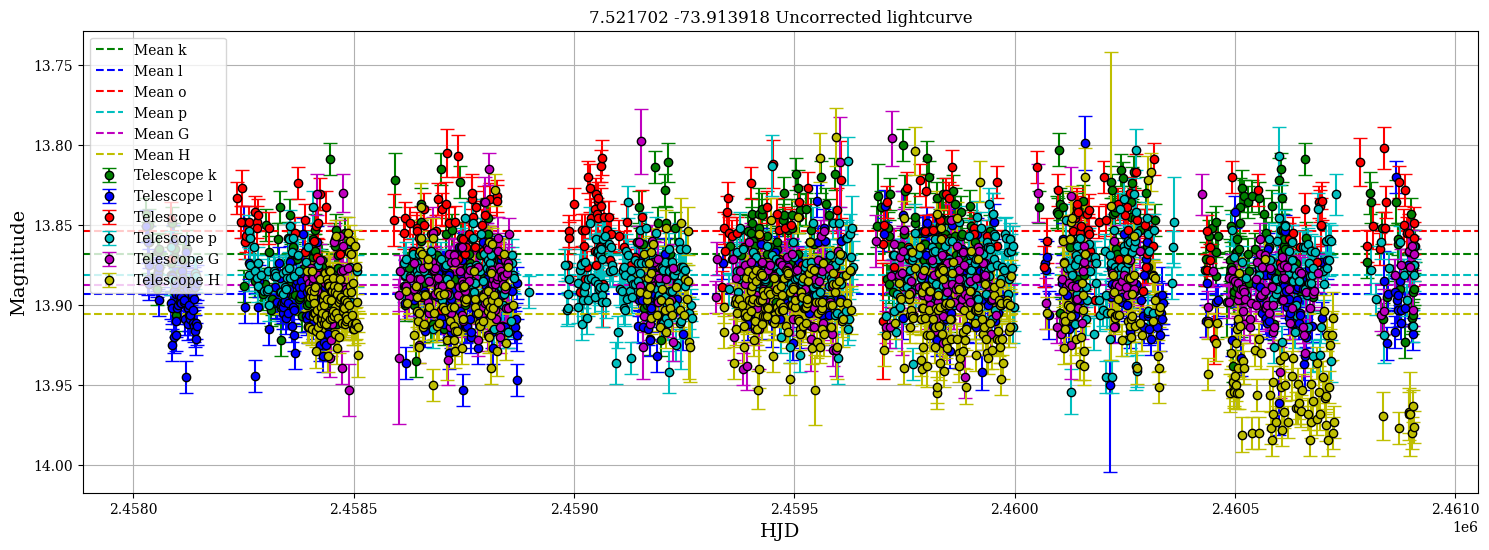

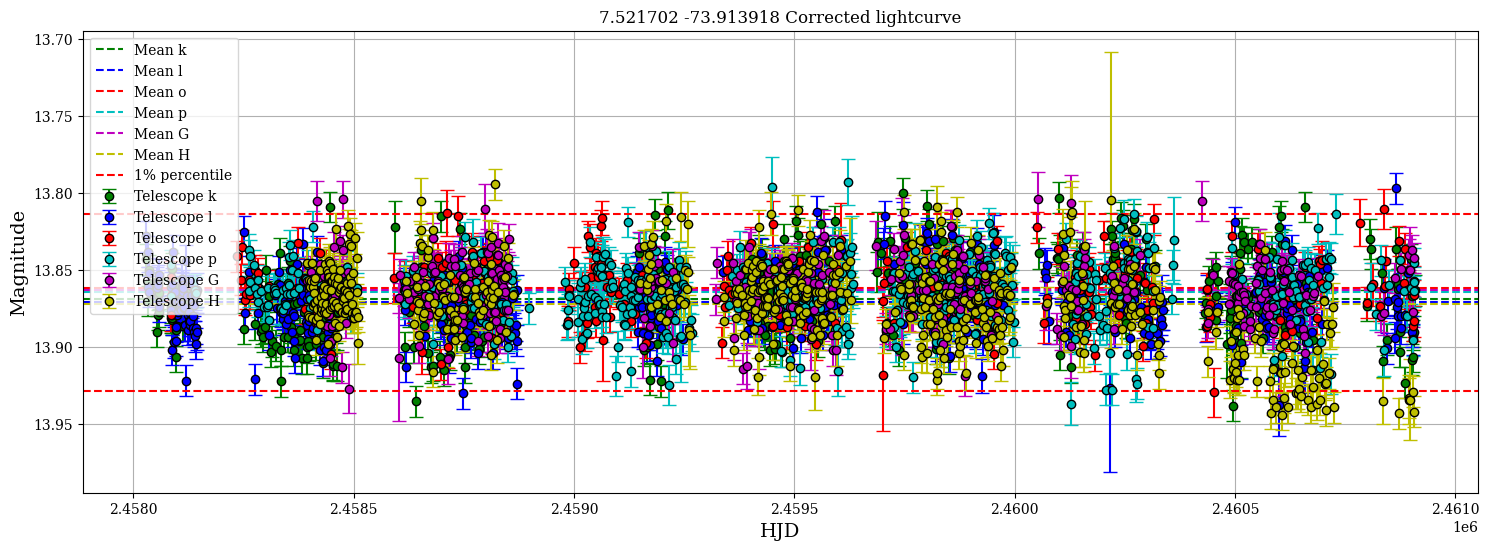

Best frequency: 0.443534 1/day, Best period: 2.25 days, Max power: 0.114, False alarm probability: 2.816e-68
False alarm level for 1.0%: 1.068e-02
Grid sampled at 24748 points


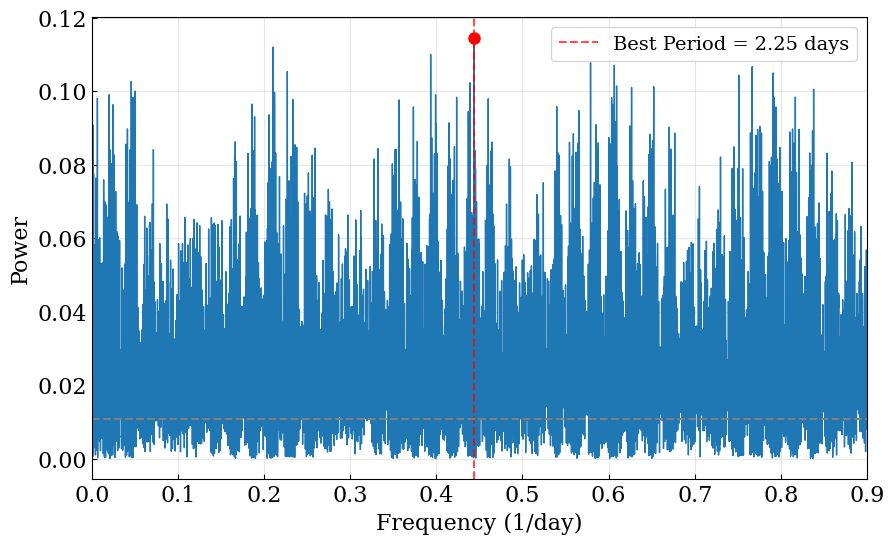

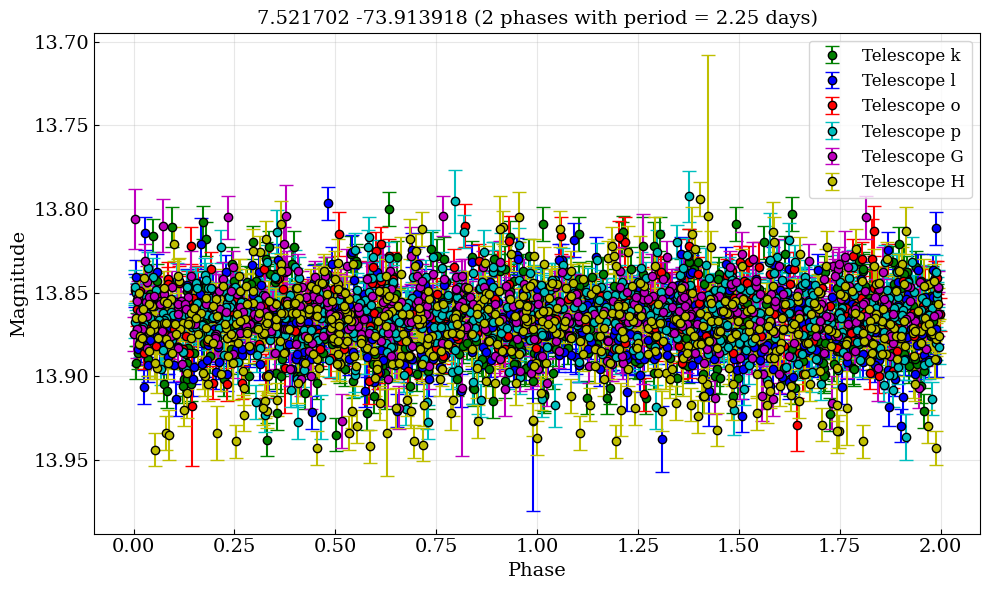

Average scatter (amplitude) per 10 point phase bin: 0.639 mJy


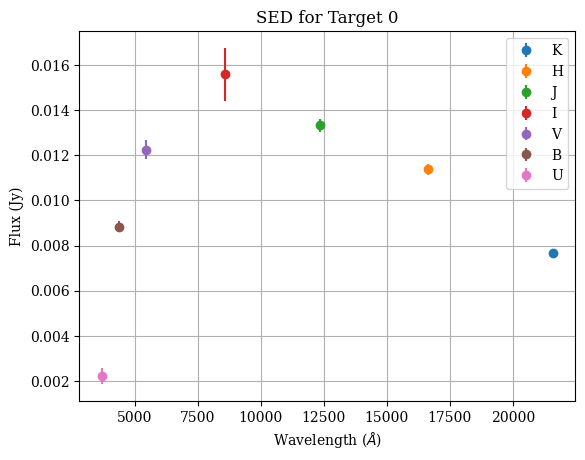

[7.31228887e-04 1.20364843e-03 1.89410776e-03 ... 8.98764441e-01
 8.99382221e-01 8.99927320e-01]
Amplitude metrics:
	Lower 5% percentile: -0.36 mJy, 13.83 mags
	Upper 5% percentile: 0.33 mJy, 13.90 mags
	Percentile amplitude of variability (excluding the brightest and dimmest 5% of data) (g-band: True): 0.69 mJy, 0.07 mags
Amplitude metrics:
	Lower 1% percentile: -0.57 mJy, 13.81 mags
	Upper 1% percentile: 0.51 mJy, 13.93 mags
	Percentile amplitude of variability (excluding the brightest and dimmest 1% of data) (g-band: True): 1.08 mJy, 0.11 mags
	Largest amplitude of variability (g-band: True): 1.43 mJy, 0.15 mags
	Average amplitude across all periods: 0.420 mJy
	Standard deviation of amplitudes: 0.215 mJy


In [ ]:
info(0)

In [ ]:
pd.read_csv('apass_trial.csv', sep = 'tab', comment='#')

/var/folders/34/3847lqd14j78mfm70_z1c_r00000gn/T/ipykernel_26684/4086419272.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  pd.read_csv('apass_trial.csv', sep = 'tab', comment='#')


,1 7.521702 -73.913918 081-000637 007.5217959 -73.9138820 3 13.889 3 13.590 2 13.519 2
0,1 7.746443 -73.741425 082-000569 007.7...
1,1 7.925977 -73.53167 083-000640 007.9...
2,1 7.948884 -73.599243 083-000650 007.9...
3,1 7.980047 -73.578545 083-000656 007.9...
4,1 7.981742 -73.585571 083-000658 007.9...
...,...
834,1 89.45843 -68.462112 108-012283 089.4...
835,1 90.085395 -70.364693 099-013609 090.0...
836,1 90.110404 -69.621155 102-017064 090.1...
837,1 90.603388 -68.215889 109-010870 090.6...


In [ ]:
apass = pd.read_csv('apass_trial_semicolon.csv', sep = ';', comment='#')

In [ ]:
print(apass.head())

                                         _1      RAJ2000 e_RAJ2000  \
0                                                    deg       mas   
1  ----------------------------------------  -----------       ---   
2  7.521702 -73.913918                       007.5217959        19   
3  7.746443 -73.741425                       007.7464995        19   
4  7.925977 -73.53167                        007.9259677        18   

       DEJ2000 e_DEJ2000    Bmag e_Bmag    Vmag e_Vmag    gmag e_gmag    rmag  \
0          deg       mas     mag   cmag     mag   cmag     mag   cmag     mag   
1  -----------       ---  ------     --  ------     --  ------     --  ------   
2  -73.9138820        19  14.173      2  13.705      3  13.889      3  13.590   
3  -73.7414187        18  14.441      3  13.926      2  14.107      0  13.782   
4  -73.5316684        18  15.788      1  14.438      3  15.086      2  14.009   

  e_rmag    imag e_imag  
0   cmag     mag   cmag  
1     --  ------     --  
2      2  13.5

In [ ]:
# import re

# # Read the file
# with open('apass_trial_semicolon.csv', 'r') as f:
#     lines = f.readlines()

# # Process each line
# fixed_lines = []
# for line in lines:
#     # Find the first space before the first semicolon and replace it with a semicolon
#     # This will split the coordinate pair in the first column
#     match = re.search(r'^([^;]+?)\s+([^;]+?)\s*;', line)
#     if match:
#         # Replace the space between coordinates with a semicolon
#         fixed_line = re.sub(r'^([^;]+?)\s+([^;]+?)\s*;', r'\1;\2;', line)
#         fixed_lines.append(fixed_line)
#     else:
#         # Keep line as is if pattern doesn't match (like header rows)
#         fixed_lines.append(line)

# # Write to a new file
# with open('apass_trial_semicolon_edited.csv', 'w') as f:
#     f.writelines(fixed_lines)

# print(f"Processed {len(fixed_lines)} lines")
# print("\nFirst few lines of the corrected file:")
# for i, line in enumerate(fixed_lines[:5]):
#     print(f"Line {i+1}: {line.strip()}")

Processed 1698 lines

First few lines of the corrected file:
Line 1: _1;RAJ2000;e_RAJ2000;DEJ2000;e_DEJ2000;Bmag;e_Bmag;Vmag;e_Vmag;gmag;e_gmag;rmag;e_rmag;imag;e_imag
Line 2: ;deg;mas;deg;mas;mag;cmag;mag;cmag;mag;cmag;mag;cmag;mag;cmag
Line 3: ----------------------------------------;-----------;---;-----------;---;------;--;------;--;------;--;------;--;------;--
Line 4: 7.521702;-73.913918;007.5217959; 19;-73.9138820; 19;14.173; 2;13.705; 3;13.889; 3;13.590; 2;13.519; 2
Line 5: 


In [ ]:
import pandas as pd

,ra,dec,RAJ2000,e_RAJ2000,DEJ2000,e_DEJ2000,Bmag,e_Bmag,Vmag,e_Vmag,gmag,e_gmag,rmag,e_rmag,imag,e_imag
0,7.521702,-73.913918,7.521796,19.0,-73.913882,19.0,14.173,2,13.705,3,13.889,3,13.590,2,13.519,2.0
1,7.746443,-73.741425,7.746499,19.0,-73.741419,18.0,14.441,3,13.926,2,14.107,0,13.782,2,13.667,4.0
2,7.925977,-73.531670,7.925968,18.0,-73.531668,18.0,15.788,1,14.438,3,15.086,2,14.009,2,13.574,3.0
3,7.948884,-73.599243,7.948827,20.0,-73.599237,20.0,15.495,3,14.311,2,14.853,2,13.907,3,13.535,5.0
4,7.980047,-73.578545,7.980023,22.0,-73.578563,19.0,16.109,5,14.566,1,15.326,2,14.127,3,13.652,1.0


In [1]:
with open("apass_xmatch_prefinalsmc.csv", "r") as infile, \
     open("apass_xmatch_prefinalsmc_fixed.csv", "w") as outfile:
    for line in infile:
        outfile.write(line.replace(";", ","))
